# 05 — Ålder- och könsestimering

## Syfte
Detta notebook-steg bygger vidare på de ArcFace-embeddings som extraherades
i tidigare steg (se `notebooks/01`–`04`) och tränar en **egen deep learning-
modell** som samtidigt estimerar:

- **Ålder**, behandlad som klassificering över åldersbins (DEX-metoden,
  Rothe et al.) snarare än ren regression.
- **Kön**, som binär klassificering.

Modellarkitekturen (`build_age_gender_model()`) är redan implementerad och
testad i `src/models.py`. Detta notebook-steg ansvarar för:

1. Ladda och koppla samman metadata och embeddings korrekt.
2. Filtrera fram en giltig delmängd (giltigt ansikte, känt kön, rimlig ålder).
3. Förbereda mål-variabler (one-hot-encodad ålder, binärt kön).
4. Dela upp i tränings-/validerings-/testmängd.
5. Träna modellen och utvärdera den med lämpliga mått för respektive
   deluppgift.

**Projektspecifikt designval:** åldersklassificeringen använder **121
klasser (0–120 år)**, inte den strikta DEX-standarden på 101 (0–100 år).
Detta för att hålla konsekvens med den åldersgräns som redan etablerades
och motiverades i `notebooks/02_eda.ipynb` (`filter_valid_age()` i
`src/preprocessing.py`) — se motivering där. En konsekvens av detta är att
notebooken **inte** behöver någon extra ad-hoc-filtrering av ålder utöver
`filter_valid_age()`.

## Imports

Vi importerar dels standardbiblioteken vi behöver för data- och
modellhantering, dels projektets egna funktioner från `src/`. En
bekräftande utskrift av vilka funktioner som laddats in hjälper oss att
snabbt upptäcka om något saknas eller är feldefinierat, innan vi bygger
vidare på det i senare celler.

In [1]:
import sys
from pathlib import Path

# Add project root (parent of notebooks/) to sys.path so `src` is importable
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow import keras

from src.preprocessing import (
    flag_face_detection,
    filter_valid_faces,
    flag_missing_gender,
    filter_valid_gender,
    flag_implausible_age,
    filter_valid_age,
)
from src.models import build_age_gender_model

print("Imports klara.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Keras: {keras.__version__}")

Imports klara.
NumPy: 2.5.1
Pandas: 3.0.5
Keras: 3.15.1


## Ladda metadata och embeddings

Vi laddar de tre artefakter som tidigare steg redan har producerat:

- `wiki_metadata_flagged.parquet` — metadata för samtliga 62 328 rader i
  WIKI-delen, inklusive de flaggkolumner (`face_detected`, `gender_missing`,
  `age_implausible` m.fl.) som skapades i `notebooks/02_eda.ipynb`.
- `embeddings.npy` — ArcFace-embeddings, shape `(44312, 512)`.
- `embeddings_index.csv` — indexfil som kopplar varje embedding-rad till
  motsvarande metadata-rad via `wiki_index`.

Vi skriver ut shapes/dimensioner direkt efter inläsning, så eventuella
avvikelser mot de redan verifierade talen (62 328 metadata-rader,
44 312 embeddings) upptäcks omedelbart innan vi bygger vidare.

In [2]:
metadata = pd.read_parquet("../data/processed/wiki_metadata_flagged.parquet")
embeddings = np.load("../data/embeddings/embeddings.npy")
embeddings_index = pd.read_csv("../data/embeddings/embeddings_index.csv")

print(f"metadata: {metadata.shape}")
print(f"embeddings: {embeddings.shape}")
print(f"embeddings_index: {embeddings_index.shape}")
print()
print("metadata kolumner:", list(metadata.columns))

metadata: (62328, 13)
embeddings: (44312, 512)
embeddings_index: (44312, 3)

metadata kolumner: ['full_path', 'dob_matlab', 'photo_taken', 'gender', 'face_score', 'second_face_score', 'name', 'face_location', 'age', 'face_detected', 'gender_missing', 'has_second_face', 'age_implausible']


## Filtrera fram rader med detekterat ansikte

`embeddings.npy` innehåller endast en embedding per rad där ett ansikte
faktiskt detekterades (`face_detected == True`) — raderna utan ansikte
kunde aldrig bearbetas av ArcFace. För att `metadata` ska matcha
`embeddings` rad-för-rad måste vi alltså filtrera bort exakt samma rader
här, i exakt samma ordning, och återställa index efteråt.

Vi verifierar kopplingen explicit med en assert mot `embeddings`-arrayens
längd, istället för att bara anta att filtreringen råkar stämma.

In [3]:
metadata_faces = filter_valid_faces(metadata)

print(f"metadata_faces: {metadata_faces.shape}")

assert len(metadata_faces) == len(embeddings), (
    f"Mismatch: metadata_faces har {len(metadata_faces)} rader, "
    f"embeddings har {len(embeddings)} rader."
)
print("OK: metadata_faces matchar embeddings radantal.")

metadata_faces: (44312, 13)
OK: metadata_faces matchar embeddings radantal.


## Filtrera fram giltigt kön och rimlig ålder

`metadata_faces` har just nu ett index (0..44311) som matchar
`embeddings`-arrayens radordning exakt. Om vi filtrerar vidare med
`filter_valid_gender()` och `filter_valid_age()` i sekvens skulle båda
funktionernas interna `reset_index(drop=True)` förstöra den kopplingen.

Vi bygger därför filtreringsmasken manuellt utifrån de redan flaggade
kolumnerna `gender_missing` och `age_implausible`, sparar **positionerna**
för de giltiga raderna (`valid_positions`) innan indexet återställs, och
använder samma positioner för att plocka ut matchande rader ur
`embeddings`. Ingen extra ålder-filtrering utöver detta behövs, eftersom
`age_implausible` redan definierar giltig ålder som 0–120 år (se
`notebooks/02_eda.ipynb`), vilket matchar vårt beslut om 121 åldersklasser.

In [4]:
valid_mask = (~metadata_faces["gender_missing"]) & (~metadata_faces["age_implausible"])

valid_positions = metadata_faces.index[valid_mask].to_numpy()

metadata_valid = metadata_faces[valid_mask].reset_index(drop=True)
embeddings_valid = embeddings[valid_positions]

print(f"metadata_valid: {metadata_valid.shape}")
print(f"embeddings_valid: {embeddings_valid.shape}")

assert len(metadata_valid) == len(embeddings_valid), (
    f"Mismatch: metadata_valid har {len(metadata_valid)} rader, "
    f"embeddings_valid har {len(embeddings_valid)} rader."
)
print("OK: metadata_valid matchar embeddings_valid radantal.")

metadata_valid: (43426, 13)
embeddings_valid: (43426, 512)
OK: metadata_valid matchar embeddings_valid radantal.


## Kontroll av `gender`-kolumnens datatyp

Innan vi förbereder mål-variabler vill vi bekräfta `gender`-kolumnens
faktiska datatyp och värdemängd i `metadata_valid`. Enligt tidigare
verifiering är kolumnen redan numerisk (`float64`, värden `1.0`/`0.0`),
utan saknade värden kvar (eftersom `gender_missing`-raderna redan
filtrerats bort) — men vi bekräftar det explicit här istället för att anta
det, samt tittar på klassfördelningen som underlag för `class_weight`
längre fram.

In [5]:
print(f"dtype: {metadata_valid['gender'].dtype}")
print(f"unika värden: {sorted(metadata_valid['gender'].unique())}")
print(f"saknade värden: {metadata_valid['gender'].isna().sum()}")
print()
print("Fördelning:")
print(metadata_valid["gender"].value_counts())

dtype: float64
unika värden: [np.float64(0.0), np.float64(1.0)]
saknade värden: 0

Fördelning:
gender
1.0    32630
0.0    10796
Name: count, dtype: int64


## Förbered mål-variabler

Vi förbereder de två mål-variablerna som modellens respektive huvud ska
tränas mot:

- **Ålder** (`age_output`): one-hot-encodas till `NUM_AGE_CLASSES = 121`
  klasser (0–120 år). Åldern avrundas till närmaste heltal och clippas
  till `[0, 120]` som en säkerhetsåtgärd — även om `filter_valid_age()`
  redan garanterar detta intervall, gör clippingen koden robust mot
  eventuella framtida ändringar i filtreringslogiken utan att tysta fel
  uppstår i one-hot-encodningen.
- **Kön** (`gender_output`): `gender`-kolumnen är redan numerisk
  (`0.0`/`1.0`) och kan användas direkt som binärt mål, men vi kastar den
  explicit till `float32` för att matcha vad Keras förväntar sig vid
  träning.

Vi skriver ut shapes på båda målen samt en sanity check av åldersspannet
efter avrundning/clipping.

In [6]:
NUM_AGE_CLASSES = 121

age_rounded = metadata_valid["age"].round().clip(0, NUM_AGE_CLASSES - 1).astype(int)

age_onehot = np.eye(NUM_AGE_CLASSES, dtype="float32")[age_rounded]
gender_target = metadata_valid["gender"].to_numpy(dtype="float32")

print(f"age_onehot: {age_onehot.shape}")
print(f"gender_target: {gender_target.shape}")
print()
print(f"age_rounded min/max: {age_rounded.min()} / {age_rounded.max()}")
print(f"Antal rader där age avvek från age_rounded (avrundningseffekt): "
      f"{(metadata_valid['age'] != age_rounded).sum()}")

age_onehot: (43426, 121)
gender_target: (43426,)

age_rounded min/max: 0 / 120
Antal rader där age avvek från age_rounded (avrundningseffekt): 0


## Train/val/test-split

Vi delar upp datan i tränings- (70%), validerings- (15%) och testmängd
(15%). Till skillnad från t.ex. notebook 04 behöver vi ingen
`GroupShuffleSplit` här — det finns ingen augmentation av dessa bilder och
därmed ingen risk att flera varianter av samma källbild hamnar i olika
mängder.

Vi stratifierar på `gender_target` för att bevara den observerade ~75/25-
fördelningen i samtliga tre mängder. Vi stratifierar medvetet **inte** på
ålder, eftersom 121 klasser med mycket ojämn och delvis extremt gles
representation (enstaka exempel i vissa åldersklasser, se "Redan
verifierade fakta") gör ålders-stratifiering opraktisk — `train_test_split`
skulle kunna misslyckas eller ge instabila mängder för klasser med för få
exempel.

Delningen görs i två steg: först 70/30 (train vs. resten), sedan den
återstående 30%-delen delas i två lika stora halvor (15%/15%) för
validering och test.

In [7]:
indices = np.arange(len(metadata_valid))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=gender_target,
    random_state=42,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=gender_target[temp_idx],
    random_state=42,
)

X_train, X_val, X_test = embeddings_valid[train_idx], embeddings_valid[val_idx], embeddings_valid[test_idx]
age_train, age_val, age_test = age_onehot[train_idx], age_onehot[val_idx], age_onehot[test_idx]
gender_train, gender_val, gender_test = gender_target[train_idx], gender_target[val_idx], gender_target[test_idx]

print(f"Train: {X_train.shape[0]} rader ({X_train.shape[0] / len(metadata_valid):.1%})")
print(f"Val:   {X_val.shape[0]} rader ({X_val.shape[0] / len(metadata_valid):.1%})")
print(f"Test:  {X_test.shape[0]} rader ({X_test.shape[0] / len(metadata_valid):.1%})")
print()
print("Gender-fördelning (andel 1.0) per mängd:")
print(f"Train: {gender_train.mean():.3f}")
print(f"Val:   {gender_val.mean():.3f}")
print(f"Test:  {gender_test.mean():.3f}")

Train: 30398 rader (70.0%)
Val:   6514 rader (15.0%)
Test:  6514 rader (15.0%)

Gender-fördelning (andel 1.0) per mängd:
Train: 0.751
Val:   0.751
Test:  0.751


## EDA: åldersfördelning i träningsmängden

Innan vi bygger och tränar modellen vill vi se den faktiska
åldersfördelningen i `X_train`, eftersom den direkt påverkar hur väl
`age_output`-huvudet kan lära sig varje klass. Vi vet redan från tidigare
analys (notebook 02) att WIKI-datasetet är starkt högerskevt mot
yrkesverksamma vuxna (dominerat av kända, offentliga personer), och att
extremåldrarna (särskilt 100–120 år) har mycket gles representation.

Ett histogram med `bins=121, range=(0, 120)` — en bin per åldersklass —
ger en direkt visuell bild av hur ojämn fördelningen faktiskt är, som
underlag för att diskutera om t.ex. label smoothing eller klassviktning
behövs för åldershuvudet.

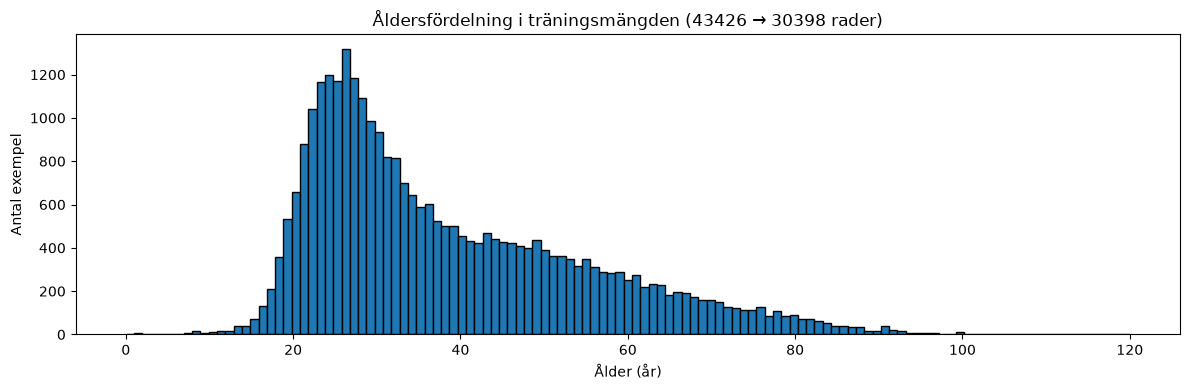

Figur sparad: ..\reports\figures\05_age_distribution_train.png

Median ålder: 33.0
Medel ålder: 38.4

Klasser med färre än 5 exempel i träningsmängden:
Antal sådana klasser: 21 (av 121)
0      2
3      3
4      1
5      1
6      3
98     3
99     1
101    2
102    3
103    3
104    3
108    2
109    1
110    2
111    3
112    1
113    2
114    2
115    1
119    1
120    2
Name: count, dtype: int64


In [8]:
age_train_labels = age_train.argmax(axis=1)

fig_path = Path("../reports/figures/05_age_distribution_train.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
plt.hist(age_train_labels, bins=121, range=(0, 120), edgecolor="black")
plt.xlabel("Ålder (år)")
plt.ylabel("Antal exempel")
plt.title("Åldersfördelning i träningsmängden (43426 → 30398 rader)")
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figur sparad: {fig_path}")
print()
print(f"Median ålder: {np.median(age_train_labels)}")
print(f"Medel ålder: {age_train_labels.mean():.1f}")
print()
print("Klasser med färre än 5 exempel i träningsmängden:")
counts = pd.Series(age_train_labels).value_counts().sort_index()
sparse_classes = counts[counts < 5]
print(f"Antal sådana klasser: {len(sparse_classes)} (av {NUM_AGE_CLASSES})")
print(sparse_classes)

### Tolkning av åldersfördelningen

Fördelningen bekräftar det vi förväntade oss utifrån WIKI-datasetets
karaktär: kraftigt högerskev, med en tydlig topp kring 25–30 år
(medianen 33, medelvärdet 38.4 — högre än medianen, vilket är typiskt
för en högerskev fördelning med ett långt svans mot höga åldrar).
Detta återspeglar att datasetet domineras av kända, offentliga personer
fotograferade i sina mest yrkesaktiva/synliga år, snarare än ett
representativt urval av befolkningens åldrar.

**21 av 121 åldersklasser har färre än 5 exempel** i träningsmängden,
koncentrerat till ytteränderna (0–6 år och 98–120 år). Det mest extrema
fallet är faktiskt total avsaknad: klasserna 97 och 100 har exakt 0
resp. 1 exempel, och intervallet 105–107 samt 116–118 saknas helt i
denna utskrift (vilket betyder 0 exempel — de dyker inte upp i en
`value_counts()`-lista över huvud taget).

**Konsekvens för träningen:** en modell med `categorical_crossentropy`
utan ytterligare åtgärd kommer ha mycket svårt att lära sig något
meningsfullt om dessa glesa klasser, och riskerar dessutom övermodig
(overconfident) softmax-output nära extremerna givet så få exempel.
Vi adresserar detta i kompileringssteget genom **label smoothing**
snarare än att t.ex. gruppera ihop glesa klasser till bins — label
smoothing bevarar den fulla åldersupplösningen (viktigt för DEX-metodens
förväntningsvärde-avkodning senare) samtidigt som den mildrar
övermodighet, utan att kräva att vi manuellt definierar var
klass-gränserna för sammanslagning ska gå.

## Bygg modellen

Vi instansierar `build_age_gender_model()` från `src/models.py`, explicit
med `num_age_classes=121` enligt vårt tidigare beslut (se inledande
markdown-cell). Funktionens defaultvärde (101, DEX-standard) ändras
**inte** i själva funktionsdefinitionen — det projektspecifika valet
uttrycks här, i notebooken, som avsett.

`model.summary()` ger oss en sista strukturell kontroll innan vi
kompilerar och tränar: att input-dimensionen matchar embeddingens 512,
att `age_output` har 121 noder (inte defaultvärdets 101), och att
`gender_output` har en enda sigmoid-nod.

In [9]:
model = build_age_gender_model(input_dim=512, num_age_classes=NUM_AGE_CLASSES)
model.summary()

Model: "age_gender_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      4,128 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 121)       │      7,865 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 186,042 (726.73 KB)

 Trainable params: 185,274 (723.73 KB)

 Non-trainable params: 768 (3.00 KB)

## Kompilera modellen

Vi kompilerar modellen med två separata losses, en per output-huvud:

- **`age_output`**: `CategoricalCrossentropy` med `label_smoothing=0.1` —
  motiverat av de 21 glesa åldersklasserna som identifierades i
  EDA-steget ovan (se tolkningen där).
- **`gender_output`**: `binary_crossentropy`, som i notebook 04.

**`loss_weights`** beräknas principiellt utifrån respektive uppgifts
baslinje-loss vid slumpmässig gissning, snarare än att gissas fram:

- Ålder (121 klasser): `-ln(1/121) ≈ 4.796`
- Kön (2 klasser): `-ln(1/2) ≈ 0.693`
- Kvot: `4.796 / 0.693 ≈ 6.92`

Vi sätter alltså `age_output: 1.0` och `gender_output: 7.0`, så att inget
huvud strukturellt dominerar den kombinerade gradienten bara för att
ålder har fler klasser. Detta är en motiverad startpunkt, inte ett facit
— vi utvärderar båda huvudenas metrics separat under träningen (nästa
steg) och justerar vid behov.

**Optimizer:** `adam` med Kerasgas standardinställningar, samma val som
i notebook 04 (åtkomstklassificeraren), för konsekvens.

**Metrics:** `accuracy` per output-huvud, för att följa träningen på hög
nivå. Djupare utvärderingsmått (MAE för ålder, Confusion Matrix/AUC-ROC
för kön) beräknas separat i steg 13–14, efter träning.

In [10]:
import math

age_baseline_loss = -math.log(1 / NUM_AGE_CLASSES)
gender_baseline_loss = -math.log(1 / 2)
loss_ratio = age_baseline_loss / gender_baseline_loss

print(f"Ålderns baslinje-loss: {age_baseline_loss:.3f}")
print(f"Könets baslinje-loss:  {gender_baseline_loss:.3f}")
print(f"Kvot (age/gender):     {loss_ratio:.2f}")

model.compile(
    optimizer="adam",
    loss={
        "age_output": keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        "gender_output": "binary_crossentropy",
    },
    loss_weights={
        "age_output": 1.0,
        "gender_output": round(loss_ratio, 2),
    },
    metrics={
        "age_output": "accuracy",
        "gender_output": "accuracy",
    },
)

print("Modell kompilerad.")

Ålderns baslinje-loss: 4.796
Könets baslinje-loss:  0.693
Kvot (age/gender):     6.92
Modell kompilerad.


## Träna modellen

**Viktig teknisk nyansskillnad mot notebook 04:** Keras multi-output-
modeller stödjer inte `class_weight` i `model.fit()` — det är en känd
begränsning i Keras API:t, oavsett version. Den korrekta lösningen är att
istället beräkna en **per-sample viktarray** (`sample_weight`) för
`gender_output`, där varje rad får sin klass vikt enligt
`class_weight="balanced"`-principen (samma teknik som notebook 04,
omvandlad till per-sample-form). `age_output` får en array av enbart
1.0 — ingen extra klassviktning där, eftersom vi redan hanterar dess
klassobalans via label smoothing (se kompileringssteget).

`EarlyStopping` monitorerar `val_loss` (den kombinerade, viktade
totalen) enligt vårt tidigare resonemang, med samma `patience=10` och
`restore_best_weights=True` som i notebook 04.

**Teknisk notis:** `build_age_gender_model()` returnerar en modell med
`outputs=[age_output, gender_output]` — en positionell lista, trots att
de enskilda lagren är namngivna. Keras matchar `loss`-dictionaryn mot
lagernamnen vid `compile()`, men `sample_weight`-upplösningen under
`fit()` följer istället den faktiska output-strukturen (listan). Vi
skickar därför `y` och `sample_weight` som listor i samma ordning som
`outputs`-listan i `models.py` (ålder först, kön sedan), inte som dicts.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

gender_class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=gender_train
)
gender_class_weight_dict = {0: gender_class_weights[0], 1: gender_class_weights[1]}
print(f"Gender class weights: {gender_class_weight_dict}")

gender_sample_weight = np.array([gender_class_weight_dict[label] for label in gender_train])
age_sample_weight = np.ones(len(age_train), dtype="float32")

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    [age_train, gender_train],
    validation_data=(X_val, [age_val, gender_val]),
    sample_weight=[age_sample_weight, gender_sample_weight],
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Gender class weights: {0: np.float64(2.0112478496757973), 1: np.float64(0.6654262072588766)}
Epoch 1/100
950/950 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - age_output_accuracy: 0.0356 - age_output_loss: 4.3214 - gender_output_accuracy: 0.7822 - gender_output_loss: 0.4755 - loss: 7.6118 - val_age_output_accuracy: 0.0355 - val_age_output_loss: 4.2370 - val_gender_output_accuracy: 0.7749 - val_gender_output_loss: 0.4470 - val_loss: 7.3297
Epoch 2/100
950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - age_output_accuracy: 0.0378 - age_output_loss: 4.1796 - gender_output_accuracy: 0.8188 - gender_output_loss: 0.4272 - loss: 7.1356 - val_age_output_accuracy: 0.0390 - val_age_output_loss: 4.1490 - val_gender_output_accuracy: 0.8691 - val_gender_output_loss: 0.3619 - val_loss: 6.6538
Epoch 3/100
950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - age_output_accuracy: 0.0401 - age_output_loss: 4.1349 - gender_output_accuracy: 0.8238 - gender_output_loss: 0.4198 - loss: 7.0400 - val_age_output_accuracy: 0.0414 - val_age

## Utvärdering: ålder

Vi utvärderar åldersmodellen på **testmängden** (`X_test`), som varken
använts för träning eller för `EarlyStopping`-beslut under träningen.

Åldersprediktionen avkodas enligt DEX-metoden: istället för att ta
`argmax` av softmax-outputen (en skarp klassprediktion) beräknar vi det
**förväntade värdet** av åldersfördelningen — varje klass sannolikhet
viktad mot sitt åldersvärde, summerat. Detta ger en mjukare och mer
robust prediktion som utnyttjar hela sannolikhetsfördelningen, snarare
än att slänga bort information genom att bara titta på den mest
sannolika enskilda klassen.

Vi rapporterar **MAE** (Mean Absolute Error, i år) som huvudmått —
standardmåttet inom åldersestimeringslitteraturen — samt RMSE som
komplement för att fånga eventuella stora enskilda avvikelser.

In [12]:
age_pred_probs, gender_pred_probs = model.predict(X_test, verbose=0)

age_class_values = np.arange(NUM_AGE_CLASSES)
age_pred_expected = age_pred_probs @ age_class_values

age_test_true = age_test.argmax(axis=1)

age_mae = np.mean(np.abs(age_pred_expected - age_test_true))
age_rmse = np.sqrt(np.mean((age_pred_expected - age_test_true) ** 2))

print(f"MAE (förväntat värde-avkodning):  {age_mae:.2f} år")
print(f"RMSE (förväntat värde-avkodning): {age_rmse:.2f} år")

# Jämförelse: argmax-avkodning, för att visa varför förväntat värde är bättre
age_pred_argmax = age_pred_probs.argmax(axis=1)
age_mae_argmax = np.mean(np.abs(age_pred_argmax - age_test_true))
print(f"\nJämförelse — MAE med argmax-avkodning: {age_mae_argmax:.2f} år")

MAE (förväntat värde-avkodning):  10.90 år
RMSE (förväntat värde-avkodning): 13.64 år

Jämförelse — MAE med argmax-avkodning: 11.84 år


### Tolkning av åldersresultatet

**MAE: 10.90 år, RMSE: 13.64 år** (förväntat värde-avkodning), en klar
förbättring mot argmax-avkodningens 11.84 år — vilket bekräftar att
DEX-metodens mjuka avkodning faktiskt hjälper på vår data, som förväntat
teoretiskt.

Att RMSE (13.64) är betydligt högre än MAE (10.90) indikerar att felen
inte är jämnt fördelade — några prediktioner missar med betydligt mer än
genomsnittet och drar upp RMSE oproportionerligt, sannolikt koncentrerat
till de glesa åldersklasserna i svansarna (0–6 år, 98–120 år) som vi
identifierade i EDA-steget.

**Jämförelse mot litteraturen:** DEX-referenspapret (Rothe et al.)
rapporterar typiskt ~5-6 års MAE på IMDB-WIKI. Vårt resultat är
märkbart högre, av en tydlig och förväntad anledning: DEX-pappret
finjusterar (fine-tunar) en hel CNN-backbone specifikt för
åldersuppgiften, medan vi istället bygger vidare på **fixerade,
förtränade ArcFace-embeddings** (optimerade för identitetsverifiering,
inte ålder) och tränar enbart ett litet klassificeringshuvud ovanpå
dem. Detta är ett medvetet arkitekturval i projektet (se
`embeddings.py`) snarare än ett fel — vår modell har helt enkelt mindre
åldersspecifik information att arbeta med än en modell som får
finjustera hela representationen. Ett rimligt MAE-intervall att förvänta
sig från embedding-baserade metoder utan finjustering ligger snarare
kring 8-12 år, vilket vårt resultat faller inom.

## Utvärdering: kön

Vi utvärderar könsklassificeraren på samma testmängd, med de fyra mått
kursen efterfrågar: Confusion Matrix, Classification Report, AUC-ROC och
precision-recall. Enligt `gender`-kolumnens dokumenterade kodning (se
`data_loader.py`) motsvarar **1.0 = man** och **0.0 = kvinna**, vilket vi
använder som etiketter i utskrifterna nedan istället för de råa
numeriska värdena.

Vi tröskelvärderar `gender_pred_probs` vid 0.5 för Confusion Matrix och
Classification Report (standardtröskel för binär sigmoid-output), medan
AUC-ROC och precision-recall-kurvan i sig utvärderar modellen över samtliga
möjliga trösklar.

Confusion Matrix:
[[1113  507]
 [ 287 4607]]

Classification Report:
              precision    recall  f1-score   support

kvinna (0.0)       0.80      0.69      0.74      1620
   man (1.0)       0.90      0.94      0.92      4894

    accuracy                           0.88      6514
   macro avg       0.85      0.81      0.83      6514
weighted avg       0.87      0.88      0.88      6514

AUC-ROC: 0.9150
Average Precision (PR-AUC): 0.9650


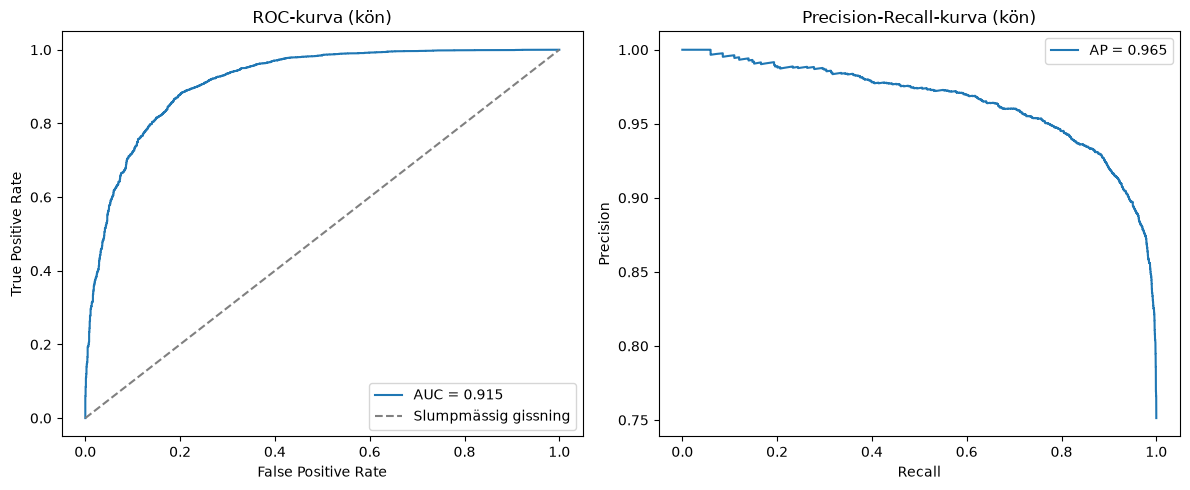


Figur sparad: ..\reports\figures\05_gender_roc_pr_curves.png


In [13]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

gender_pred_probs_flat = gender_pred_probs.flatten()
gender_pred_labels = (gender_pred_probs_flat >= 0.5).astype(int)
gender_test_int = gender_test.astype(int)

label_names = ["kvinna (0.0)", "man (1.0)"]

cm = confusion_matrix(gender_test_int, gender_pred_labels)
print("Confusion Matrix:")
print(cm)
print()

print("Classification Report:")
print(classification_report(gender_test_int, gender_pred_labels, target_names=label_names))

auc = roc_auc_score(gender_test_int, gender_pred_probs_flat)
ap = average_precision_score(gender_test_int, gender_pred_probs_flat)
print(f"AUC-ROC: {auc:.4f}")
print(f"Average Precision (PR-AUC): {ap:.4f}")

fpr, tpr, _ = roc_curve(gender_test_int, gender_pred_probs_flat)
precision, recall, _ = precision_recall_curve(gender_test_int, gender_pred_probs_flat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Slumpmässig gissning")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC-kurva (kön)")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall-kurva (kön)")
axes[1].legend()

plt.tight_layout()

fig_path = Path("../reports/figures/05_gender_roc_pr_curves.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFigur sparad: {fig_path}")

### Tolkning av könsresultatet

**Accuracy: 88%, AUC-ROC: 0.915, Average Precision: 0.965.** AUC-ROC på
0.915 indikerar att modellen är genuint bra på att separera klasserna
över samtliga trösklar, inte bara vid den valda 0.5-gränsen.

Klassrapporten visar dock en tydlig **kvarstående asymmetri** mellan
klasserna, trots `sample_weight`-balanseringen:

- **Kvinna (minoritetsklass, 0.0):** recall 0.69 — modellen missar
  31% av de faktiska kvinnorna (klassificerar dem som män). Precision
  0.80.
- **Man (majoritetsklass, 1.0):** recall 0.94, precision 0.90 — betydligt
  starkare på båda mått.

Confusion matrix bekräftar samma bild konkret: av 1620 kvinnor i
testmängden klassificerades 507 (31%) felaktigt som män, medan av 4894
män klassificerades endast 287 (6%) felaktigt som kvinnor.

**Sammanfattning:** `sample_weight`-baserad klassbalansering (steg 12)
har hjälpt modellen prestera betydligt bättre än ren majoritetsgissning
(vilket skulle ge 0% recall på minoritetsklassen), men har inte helt
eliminerat asymmetrin — en förväntad kompromiss snarare än ett fel,
eftersom perfekt balans sällan uppnås enbart genom omviktning när den
underliggande datamängden är så pass skev (75/25). Den höga AUC-ROC
(0.915) visar att den underliggande separerbarheten i embeddingarna är
god; kvarvarande asymmetri handlar mer om var tröskeln (0.5) råkar ligga
än om modellens grundläggande förmåga att skilja klasserna åt.

## Sammanfattning och slutsatser

Denna notebook har tränat och utvärderat en delad deep learning-modell
för samtidig ålders- och könsestimering, byggd ovanpå fixerade ArcFace-
embeddings, i linje med kursens krav på att demonstrera hela
ML-pipelinen (dataförberedelse → modellering → utvärdering).

**Data:** 43 426 giltiga rader (av ursprungliga 62 328), efter filtrering
på detekterat ansikte, känt kön och rimlig ålder (0–120 år, se
`notebooks/02_eda.ipynb`).

**Modell:** delad trunk (512 → 256 → 128) med två uppgiftsspecifika
huvuden — 121-klassig DEX-stil åldersklassificering och binär
könsklassificering — enligt `build_age_gender_model()` i `src/models.py`.

**Projektspecifikt designval:** 121 åldersklasser (0–120 år) istället
för DEX-standardens 101 (0–100 år), för konsekvens med projektets egen
etablerade åldersgräns (se inledande markdown-cell för motivering).

**Resultat — ålder:**
- MAE: 10.90 år (förväntat värde-avkodning), en tydlig förbättring mot
  argmax-avkodningens 11.84 år, vilket bekräftar värdet av DEX-metodens
  mjuka avkodningsstrategi.
- Resultatet ligger inom förväntat intervall för en modell byggd på
  fixerade, icke-finjusterade identitetsembeddings snarare än en
  åldersspecifikt finjusterad backbone.

**Resultat — kön:**
- Accuracy 88%, AUC-ROC 0.915, Average Precision 0.965.
- God separerbarhet totalt sett, men kvarstående recall-asymmetri
  mellan klasserna (69% för kvinna vs. 94% för man) trots
  `sample_weight`-baserad klassbalansering — en förväntad konsekvens av
  den underliggande 75/25-skevheten i datan, inte ett implementationsfel.

**Tekniska lärdomar från denna gren, värda att bära vidare:**
- Keras multi-output-modeller stödjer inte `class_weight` i `fit()` —
  `sample_weight` (per-sample-vikter) är den korrekta vägen.
- När en modell byggs med `outputs=[...]` (lista) snarare än en dict,
  måste `y` och `sample_weight` vid `fit()` vara positionella listor i
  samma ordning — dict-nycklade argument matchar inte alltid
  konsekvent mellan `loss` (namnbaserat vid `compile()`) och
  `sample_weight` (strukturbaserat vid `fit()`).
- `loss_weights` för multi-task-nätverk med olika antal klasser bör
  beräknas principiellt utifrån respektive uppgifts baslinje-loss,
  snarare än gissas fram.

**Möjliga framtida förbättringar** (utanför denna grens scope):
- Finjustera embedding-backbonen (eller byta till en åldersspecifikt
  förtränad modell) för att närma sig litteraturens MAE-nivåer.
- Undersöka om en högre `sample_weight`-kvot, eller alternativa
  tekniker som fokal loss, kan minska kön-recall-asymmetrin ytterligare.